# 08. CVAE (Conditional VAE) — TensorFlow

VAE에 레이블 조건(action 종류)을 추가해 원하는 동작의 이미지를 생성할 수 있도록 합니다.

| 구분 | VAE | CVAE |
|------|-----|------|
| 인코더 입력 | 이미지 | 이미지 + 레이블 |
| 디코더 입력 | z | z + 레이블 |
| 생성 제어 | 불가 | 레이블로 동작 지정 가능 |

## 1. 환경 설정

In [1]:
import os, json, random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, Conv2DTranspose, BatchNormalization,
    LeakyReLU, ReLU, Flatten, Dense, Reshape, Activation
)

# fix working directory
_root = Path(os.path.abspath(''))
for _p in [_root] + list(_root.parents):
    if (_p / 'dataset' / 'processed').exists():
        os.chdir(_p); break
print(f'CWD: {Path.cwd()}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
DEVICE = '/GPU:0' if gpus else '/CPU:0'
print(f'Device: {DEVICE}')

CKPT_DIR = Path('checkpoints_cvae_tf')
CKPT_DIR.mkdir(exist_ok=True)

ACTIONS     = ['walk', 'idle', 'run', 'slash', 'shoot', 'thrust', 'jump', 'sit', 'spellcast']
NUM_CLASSES = len(ACTIONS) + 1   # + 'other'
LABEL_NAMES = ACTIONS + ['other']

CFG = {
    'latent_dim'   : 128,
    'base_channels': 32,
    'channels'     : 4,
    'num_classes'  : NUM_CLASSES,
    'epochs'       : 100,
    'batch_size'   : 128,
    'lr'           : 1e-3,
    'beta'         : 1.0,
    'patience'     : 10,
}

with open(CKPT_DIR / 'config.json', 'w') as f:
    json.dump(CFG, f, indent=2)

LATENT_DIM = CFG['latent_dim']
BASE_CH    = CFG['base_channels']
CHANNELS   = CFG['channels']
EPOCHS     = CFG['epochs']
BATCH_SIZE = CFG['batch_size']
LR         = CFG['lr']
BETA       = CFG['beta']
PATIENCE   = CFG['patience']
print('CFG:', CFG)

CWD: /Users/gomuseo/Desktop/Python/vae_test
Device: /GPU:0
CFG: {'latent_dim': 128, 'base_channels': 32, 'channels': 4, 'num_classes': 10, 'epochs': 100, 'batch_size': 128, 'lr': 0.001, 'beta': 1.0, 'patience': 10}


## 2. 레이블 정의

In [2]:
BODY_DIR  = Path('dataset/processed/body')
all_paths = sorted(BODY_DIR.glob('*.png'))

def get_label(path):
    name = Path(path).name
    for i, kw in enumerate(ACTIONS):
        if kw in name:
            return i
    return len(ACTIONS)  # 'other'

labels = [get_label(p) for p in all_paths]
dist   = Counter(LABEL_NAMES[l] for l in labels)
print('Label distribution:')
for name, cnt in sorted(dist.items(), key=lambda x: -x[1]):
    print(f'  {name:>12}: {cnt}')

Label distribution:
         slash: 1032
          walk: 864
          jump: 480
         shoot: 416
           run: 320
        thrust: 320
         other: 288
           sit: 288
     spellcast: 280
          idle: 256


## 3. 데이터셋 준비

In [3]:
# stratified train/val split (90/10)
from sklearn.model_selection import train_test_split

str_paths = [str(p) for p in all_paths]
tr_paths, vl_paths, tr_labels, vl_labels = train_test_split(
    str_paths, labels, test_size=0.1, random_state=42, stratify=labels
)
print(f'Train: {len(tr_paths)}  Val: {len(vl_paths)}')


def load_item(path, label):
    img = tf.image.decode_png(tf.io.read_file(path), channels=4)
    img = tf.cast(img, tf.float32) / 255.0
    c   = tf.one_hot(label, NUM_CLASSES)
    return img, c


def make_ds(paths, lbls, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, lbls))
    ds = ds.map(load_item, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2048, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = make_ds(tr_paths, tr_labels, shuffle=True)
val_ds   = make_ds(vl_paths, vl_labels)
print(f'Train batches: {len(train_ds)}  Val batches: {len(val_ds)}')

Train: 4089  Val: 455


Train batches: 32  Val batches: 4


2026-06-28 12:55:55.693031: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-06-28 12:55:55.693075: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-28 12:55:55.693082: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-28 12:55:55.693404: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-28 12:55:55.693419: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 4. CVAE 모델

인코더와 디코더 모두 이미지 특징 벡터에 one-hot 레이블을 concat해 조건을 주입합니다.

In [4]:
class CVAEEncoder(tf.keras.Model):
    def __init__(self, num_classes, base_ch=32, latent_dim=128):
        super().__init__()
        self.conv_block = tf.keras.Sequential([
            Conv2D(base_ch,   4, 2, padding='same'), BatchNormalization(momentum=0.9), LeakyReLU(0.2),
            Conv2D(base_ch*2, 4, 2, padding='same'), BatchNormalization(momentum=0.9), LeakyReLU(0.2),
            Conv2D(base_ch*4, 4, 2, padding='same'), BatchNormalization(momentum=0.9), LeakyReLU(0.2),
            Conv2D(base_ch*8, 4, 2, padding='same'), BatchNormalization(momentum=0.9), LeakyReLU(0.2),
            Flatten(),
        ])
        self.fc_mu = Dense(latent_dim)
        self.fc_lv = Dense(latent_dim)

    def call(self, x, c, training=False):
        h = self.conv_block(x, training=training)
        h = tf.concat([h, c], axis=-1)
        return self.fc_mu(h), self.fc_lv(h)


class CVAEDecoder(tf.keras.Model):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        start_ch = base_ch * 8
        self.fc = Dense(start_ch * 4 * 4)
        self.deconv_block = tf.keras.Sequential([
            Reshape((4, 4, start_ch)),
            Conv2DTranspose(base_ch*4, 4, 2, padding='same'), BatchNormalization(momentum=0.9), ReLU(),
            Conv2DTranspose(base_ch*2, 4, 2, padding='same'), BatchNormalization(momentum=0.9), ReLU(),
            Conv2DTranspose(base_ch,   4, 2, padding='same'), BatchNormalization(momentum=0.9), ReLU(),
            Conv2DTranspose(channels,  4, 2, padding='same'), Activation('sigmoid'),
        ])

    def call(self, z, c, training=False):
        h = self.fc(tf.concat([z, c], axis=-1))
        return self.deconv_block(h, training=training)


class CVAE(tf.keras.Model):
    def __init__(self, num_classes, base_ch=32, latent_dim=128, channels=4):
        super().__init__()
        self.encoder = CVAEEncoder(num_classes, base_ch, latent_dim)
        self.decoder = CVAEDecoder(num_classes, base_ch, latent_dim, channels)

    def reparameterize(self, mu, lv):
        return mu + tf.random.normal(tf.shape(mu)) * tf.exp(0.5 * lv)

    def call(self, x, c, training=False):
        mu, lv = self.encoder(x, c, training=training)
        z      = self.reparameterize(mu, lv)
        recon  = self.decoder(z, c, training=training)
        return recon, mu, lv


with tf.device(DEVICE):
    model = CVAE(NUM_CLASSES, BASE_CH, LATENT_DIM, CHANNELS)

# build with dummy inputs
dummy_x = tf.zeros((1, 64, 64, CHANNELS))
dummy_c = tf.zeros((1, NUM_CLASSES))
_ = model(dummy_x, dummy_c, training=False)
model.summary()

Model: "cvae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cvae_encoder (CVAEEncoder)      │ ?                      │     1,743,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cvae_decoder (CVAEDecoder)      │ ?                      │     1,260,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,004,612 (11.46 MB)

 Trainable params: 3,003,204 (11.46 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 5. 손실 함수 & 학습 준비

In [5]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LR)


def cosine_lr(epoch, total, base_lr, min_lr=1e-5):
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * epoch / total))


@tf.function
def train_step(x, c):
    with tf.GradientTape() as tape:
        recon, mu, lv = model(x, c, training=True)
        batch      = tf.cast(tf.shape(x)[0], tf.float32)
        recon_loss = tf.reduce_sum(tf.square(x - recon)) / batch
        kl_loss    = -0.5 * tf.reduce_sum(1.0 + lv - tf.square(mu) - tf.exp(lv)) / batch
        loss       = recon_loss + BETA * kl_loss
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, recon_loss, kl_loss


@tf.function
def val_step(x, c):
    recon, mu, lv = model(x, c, training=False)
    batch      = tf.cast(tf.shape(x)[0], tf.float32)
    recon_loss = tf.reduce_sum(tf.square(x - recon)) / batch
    kl_loss    = -0.5 * tf.reduce_sum(1.0 + lv - tf.square(mu) - tf.exp(lv)) / batch
    return recon_loss + BETA * kl_loss, recon_loss, kl_loss


print('Optimizer and loss functions ready.')

Optimizer and loss functions ready.


## 6. 학습

In [6]:
history = {'loss': [], 'val_loss': [], 'recon': [], 'kl': []}
best_val = float('inf')
patience_cnt = 0

for epoch in range(EPOCHS):
    # LR 업데이트
    new_lr = cosine_lr(epoch, EPOCHS, LR)
    optimizer.learning_rate.assign(new_lr)

    # train
    tr_loss = tr_recon = tr_kl = 0.0
    for x, c in train_ds:
        l, r, k = train_step(x, c)
        tr_loss += l.numpy(); tr_recon += r.numpy(); tr_kl += k.numpy()
    n = len(train_ds)
    tr_loss /= n; tr_recon /= n; tr_kl /= n

    # val
    vl_loss = vl_recon = vl_kl = 0.0
    for x, c in val_ds:
        l, r, k = val_step(x, c)
        vl_loss += l.numpy(); vl_recon += r.numpy(); vl_kl += k.numpy()
    m = max(len(val_ds), 1)
    vl_loss /= m; vl_recon /= m; vl_kl /= m

    history['loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['recon'].append(tr_recon)
    history['kl'].append(tr_kl)

    print(f'Epoch {epoch+1:>3}/{EPOCHS}  '
          f'loss={tr_loss:.2f}  recon={tr_recon:.2f}  kl={tr_kl:.2f}  '
          f'val_loss={vl_loss:.2f}  lr={new_lr:.6f}')

    # checkpoint & early stopping
    if vl_loss < best_val:
        best_val = vl_loss
        patience_cnt = 0
        model.save_weights(str(CKPT_DIR / 'best.weights.h5'))
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

model.load_weights(str(CKPT_DIR / 'best.weights.h5'))
print(f'\nBest val_loss: {best_val:.4f}')

2026-06-28 12:55:57.846682: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2026-06-28 12:56:10.248426: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-06-28 12:56:11.461783: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   1/100  loss=2184.87  recon=2143.83  kl=41.04  val_loss=761.36  lr=0.001000


2026-06-28 12:56:15.055077: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-28 12:56:15.179003: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Epoch  98/100  loss=55.03  recon=33.08  kl=21.95  val_loss=59.47  lr=0.000012


2026-06-28 13:02:03.759094: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-28 13:02:03.875056: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch  99/100  loss=54.83  recon=32.88  kl=21.95  val_loss=59.83  lr=0.000011


2026-06-28 13:02:07.554854: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-28 13:02:07.704243: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 100/100  loss=54.84  recon=33.05  kl=21.79  val_loss=59.98  lr=0.000010

Best val_loss: 59.4687


## 7. 학습 곡선

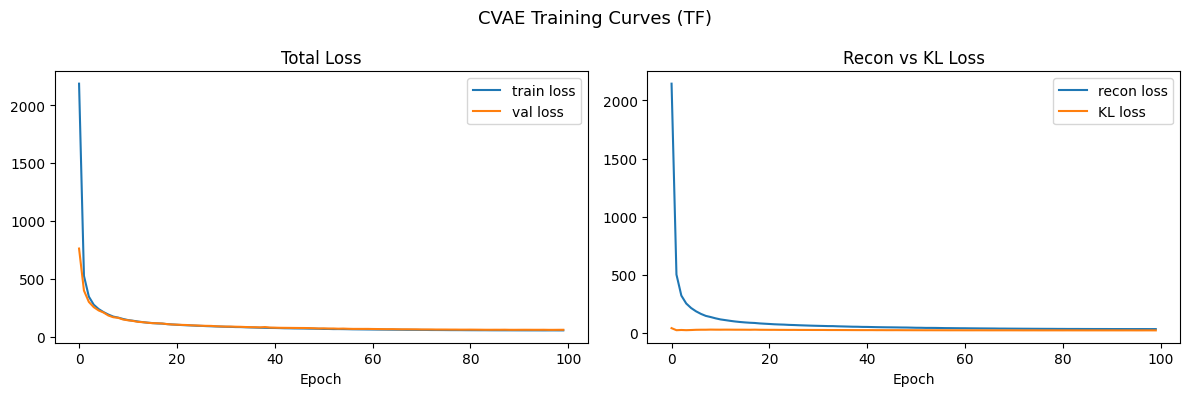

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['loss'],     label='train loss')
axes[0].plot(history['val_loss'], label='val loss')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['recon'], label='recon loss')
axes[1].plot(history['kl'],    label='KL loss')
axes[1].set_title('Recon vs KL Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.suptitle('CVAE Training Curves (TF)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. 복원 결과 확인

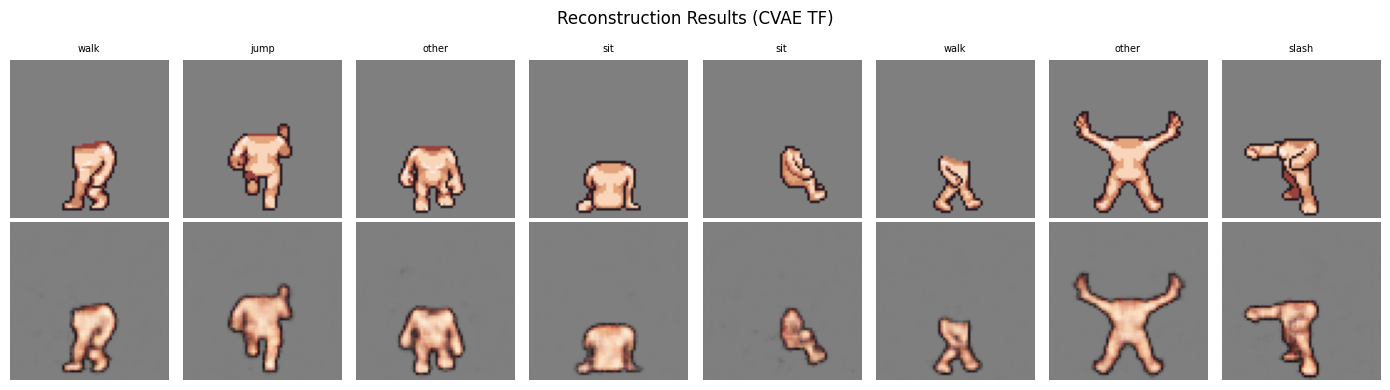

In [8]:
def composite(t):
    t = np.array(t)
    rgb, a = t[..., :3], t[..., 3:4]
    return rgb * a + np.ones_like(rgb) * 0.5 * (1 - a)


sample_x, sample_c = next(iter(val_ds))
sample_x = sample_x[:8]
sample_c = sample_c[:8]
recon, _, _ = model(sample_x, sample_c, training=False)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    lbl_idx = tf.argmax(sample_c[i]).numpy()
    axes[0, i].imshow(composite(sample_x[i].numpy()))
    axes[0, i].set_title(LABEL_NAMES[lbl_idx], fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(composite(recon[i].numpy()))
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Recon',    fontsize=9)
plt.suptitle('Reconstruction Results (CVAE TF)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. 조건부 생성

동일한 z를 사용하되 action 레이블만 바꿔 각 동작의 이미지를 생성합니다.
CVAE가 레이블을 제대로 학습했다면 동일한 z에서도 동작마다 다른 결과가 나와야 합니다.

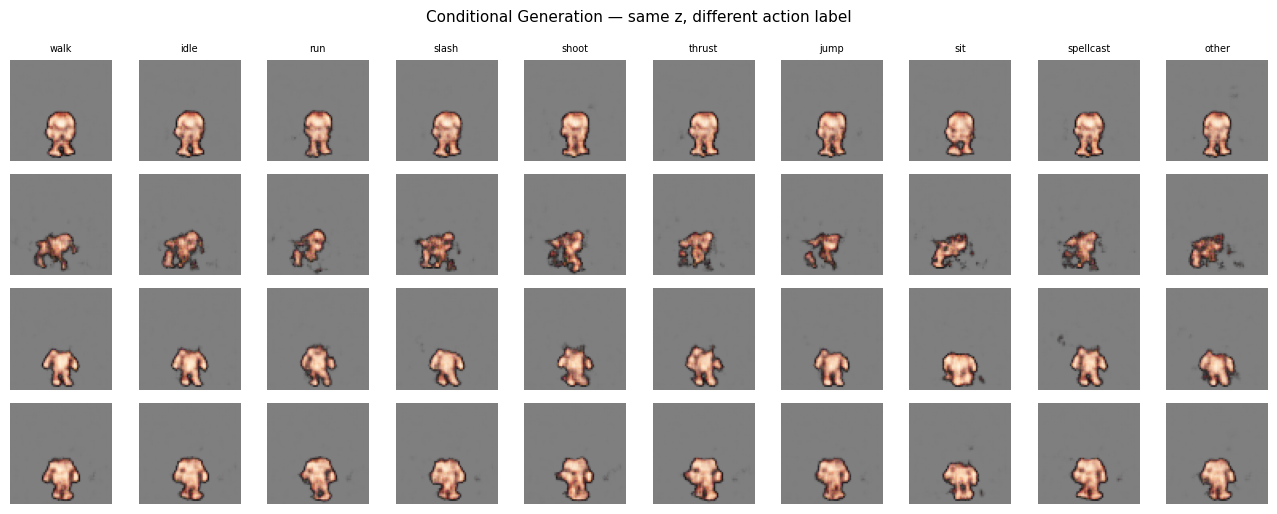

In [9]:
N_ROWS = 4
tf.random.set_seed(0)
z_samples = tf.random.normal((N_ROWS, LATENT_DIM))

fig, axes = plt.subplots(N_ROWS, NUM_CLASSES, figsize=(NUM_CLASSES * 1.3, N_ROWS * 1.3))

for row in range(N_ROWS):
    for col in range(NUM_CLASSES):
        c   = tf.one_hot([col], NUM_CLASSES)
        img = model.decoder(tf.expand_dims(z_samples[row], 0), c, training=False)
        axes[row, col].imshow(composite(img[0].numpy()))
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(LABEL_NAMES[col], fontsize=7)

plt.suptitle('Conditional Generation — same z, different action label', fontsize=11)
plt.tight_layout()
plt.show()